In [25]:
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
CROP_WEIGHTS = {
    "Brinjal":       {"climate": 0.45, "physical": 0.30, "chemical": 0.25},
    "Luffa":         {"climate": 0.50, "physical": 0.25, "chemical": 0.25},
    "Okra":          {"climate": 0.45, "physical": 0.30, "chemical": 0.25},
    "Cucumber":      {"climate": 0.50, "physical": 0.25, "chemical": 0.25},
    "Snake Gourd":   {"climate": 0.50, "physical": 0.25, "chemical": 0.25},
    "Bitter Gourd":  {"climate": 0.48, "physical": 0.27, "chemical": 0.25},
    "Radish":        {"climate": 0.35, "physical": 0.40, "chemical": 0.25},
    "Capsicum":      {"climate": 0.45, "physical": 0.25, "chemical": 0.30},
    "Yard Long Bean":{"climate": 0.45, "physical": 0.30, "chemical": 0.25},

    "Banana":        {"climate": 0.50, "physical": 0.30, "chemical": 0.20},
    "Pineapple":     {"climate": 0.45, "physical": 0.25, "chemical": 0.30},
    "Papaya":        {"climate": 0.45, "physical": 0.30, "chemical": 0.25},
    "Passion Fruit": {"climate": 0.48, "physical": 0.27, "chemical": 0.25},
    "Rambutan":      {"climate": 0.40, "physical": 0.30, "chemical": 0.30},
    "Mangosteen":    {"climate": 0.35, "physical": 0.30, "chemical": 0.35},

    "Sweet Potato":  {"climate": 0.40, "physical": 0.40, "chemical": 0.20},
    "Manioc":        {"climate": 0.45, "physical": 0.35, "chemical": 0.20},
    "Kiriala":       {"climate": 0.40, "physical": 0.40, "chemical": 0.20},
    "Yams":          {"climate": 0.40, "physical": 0.40, "chemical": 0.20},
    "Ginger":        {"climate": 0.45, "physical": 0.30, "chemical": 0.25},
    "Turmeric":      {"climate": 0.45, "physical": 0.30, "chemical": 0.25},
}

In [ ]:
CLIMATE_SPLIT = {
    "temperature_score": 0.40,
    "water_score": 0.30,
    "light_score": 0.20,
    "season_score": 0.10
}

PHYSICAL_SPLIT = {
    "texture_score": 0.35,
    "awc_score": 0.30,
    "bulk_density_score": 0.20,
    "rooting_depth_score": 0.15
}

CHEMICAL_SPLIT = {
    "ph_score": 0.40,
    "organic_carbon_score": 0.35,
    "cec_score": 0.25
}
#hdhd

In [28]:
def generate_score_for_class(target_class):
    if target_class == "Suitable":
        return random.uniform(0.75, 1.0)
    elif target_class == "Moderate":
        return random.uniform(0.45, 0.75)
    else:  # Unsuitable
        return random.uniform(0.0, 0.45)

In [29]:
import random
import pandas as pd

ROWS_PER_CROP = 100
data = []

TARGET_DISTRIBUTION = ["Suitable"] * 3 + ["Moderate"] * 4 + ["Unsuitable"] * 3

for crop, weights in CROP_WEIGHTS.items():
    for _ in range(ROWS_PER_CROP):

        target_class = random.choice(TARGET_DISTRIBUTION)

        features = {
            "temperature_score": generate_score_for_class(target_class),
            "water_score": generate_score_for_class(target_class),
            "light_score": generate_score_for_class(target_class),
            "season_score": generate_score_for_class(target_class),

            "texture_score": generate_score_for_class(target_class),
            "awc_score": generate_score_for_class(target_class),
            "bulk_density_score": generate_score_for_class(target_class),
            "rooting_depth_score": generate_score_for_class(target_class),

            "ph_score": generate_score_for_class(target_class),
            "organic_carbon_score": generate_score_for_class(target_class),
            "cec_score": generate_score_for_class(target_class),
        }

        climate_score = sum(
            features[k] * CLIMATE_SPLIT[k] for k in CLIMATE_SPLIT
        ) * weights["climate"]

        physical_score = sum(
            features[k] * PHYSICAL_SPLIT[k] for k in PHYSICAL_SPLIT
        ) * weights["physical"]

        chemical_score = sum(
            features[k] * CHEMICAL_SPLIT[k] for k in CHEMICAL_SPLIT
        ) * weights["chemical"]

        total_score = climate_score + physical_score + chemical_score
        suit_class = suitability_class(total_score)

        row = {
            "crop": crop,
            **features,
            "climate_weighted_score": round(climate_score, 3),
            "physical_weighted_score": round(physical_score, 3),
            "chemical_weighted_score": round(chemical_score, 3),
            "overall_suitability": round(total_score, 3),
            "suitability_class": suit_class
        }

        data.append(row)

df = pd.DataFrame(data)
print(df["suitability_class"].value_counts())


suitability_class
Moderate      814
Unsuitable    647
Suitable      639
Name: count, dtype: int64


In [30]:
df.to_csv("crop_suitability_training_data.csv", index=False)
print("CSV exported successfully.")

CSV exported successfully.


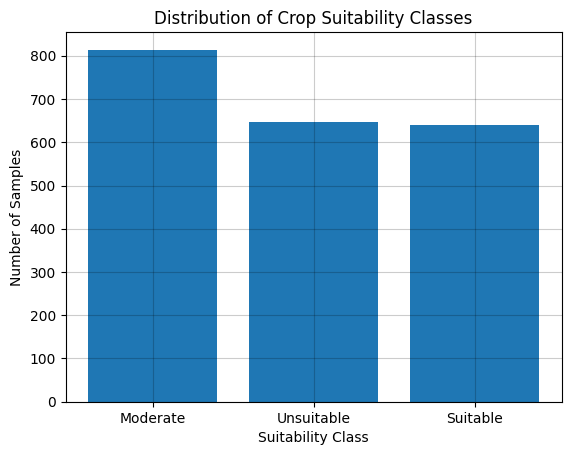

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your  dataset
df = pd.read_csv("crop_suitability_training_data.csv")

# Count classes
class_counts = df["suitability_class"].value_counts()

# Plot
plt.figure()
plt.bar(class_counts.index, class_counts.values)
plt.xlabel("Suitability Class")
plt.ylabel("Number of Samples")
plt.title("Distribution of Crop Suitability Classes")
plt.grid(True, color="black", alpha=0.2)
plt.show()